# 06 – Feature Selection: Selección de Variables

**Proyecto:** Predicción de subempleo por insuficiencia de horas – EPEN 2024  
**Target:** `target_subempleo_horas` (1 = subempleado por horas, 0 = no subempleado)

Este notebook selecciona un subconjunto de variables predictoras a partir del conjunto de entrenamiento.  
El objetivo es reducir la dimensionalidad, disminuir la redundancia y mejorar la interpretabilidad del modelo.  
La selección se realiza **después del train/test split** para evitar data leakage.

> **Regla fundamental:** toda la selección de variables se realiza exclusivamente sobre `X_train`.  
> `X_test` solo se filtra al final con la lista resultante.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 60)

print("Librerías importadas.")

Librerías importadas.


## 1. Carga de Archivos

In [2]:
SPLIT_DIR    = Path("../data/split")
SELECTED_DIR = Path("../data/selected")
SELECTED_DIR.mkdir(parents=True, exist_ok=True)

required_files = {
    "X_train": SPLIT_DIR / "X_train.csv",
    "X_test":  SPLIT_DIR / "X_test.csv",
    "y_train": SPLIT_DIR / "y_train.csv",
    "y_test":  SPLIT_DIR / "y_test.csv",
}

for name, path in required_files.items():
    if not path.exists():
        raise FileNotFoundError(
            f"Archivo requerido no encontrado: {path}\n"
            "Primero debe ejecutarse 05_train_test_splits/train_test_split.ipynb"
        )

X_train     = pd.read_csv(required_files["X_train"])
X_test      = pd.read_csv(required_files["X_test"])
y_train_raw = pd.read_csv(required_files["y_train"])
y_test_raw  = pd.read_csv(required_files["y_test"])

TARGET_COL = "target_subempleo_horas"

def extract_target(df_y, name):
    if TARGET_COL in df_y.columns:
        return df_y[TARGET_COL].reset_index(drop=True)
    if df_y.shape[1] == 1:
        return df_y.iloc[:, 0].reset_index(drop=True)
    raise ValueError(
        f"No se encontró '{TARGET_COL}' en {name}. "
        f"Columnas disponibles: {df_y.columns.tolist()}"
    )

y_train = extract_target(y_train_raw, "y_train")
y_test  = extract_target(y_test_raw,  "y_test")

print("Dimensiones:")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_train : {y_train.shape}")
print(f"  y_test  : {y_test.shape}")

Dimensiones:
  X_train : (19243, 113)
  X_test  : (4811, 113)
  y_train : (19243,)
  y_test  : (4811,)


## 2. Validaciones Iniciales

In [3]:
# 2.1 Mismas columnas en train y test
assert list(X_train.columns) == list(X_test.columns), \
    "X_train y X_test no tienen las mismas columnas."
print("OK – X_train y X_test tienen las mismas columnas.")

# 2.2 Sin nulos en target
assert y_train.isnull().sum() == 0, "y_train tiene nulos."
assert y_test.isnull().sum() == 0,  "y_test tiene nulos."
print("OK – Targets sin nulos.")

# 2.3 Solo 0 y 1
assert set(y_train.unique()).issubset({0, 1}), \
    f"y_train tiene valores fuera de {{0,1}}: {y_train.unique()}"
print(f"OK – y_train contiene: {sorted(y_train.unique())}")

# 2.4 Target no está en X
assert TARGET_COL not in X_train.columns, f"'{TARGET_COL}' está en X_train."
assert TARGET_COL not in X_test.columns,  f"'{TARGET_COL}' está en X_test."
print(f"OK – '{TARGET_COL}' no está en X_train ni X_test.")

# 2.5 Variables de leakage
LEAKAGE_VARS = ["P209H", "C333", "C334", TARGET_COL]
leaked_train = [v for v in LEAKAGE_VARS if v in X_train.columns]
leaked_test  = [v for v in LEAKAGE_VARS if v in X_test.columns]
if leaked_train:
    print(f"ADVERTENCIA – Eliminando de X_train: {leaked_train}")
    X_train = X_train.drop(columns=leaked_train)
if leaked_test:
    print(f"ADVERTENCIA – Eliminando de X_test: {leaked_test}")
    X_test = X_test.drop(columns=leaked_test)
if not leaked_train and not leaked_test:
    print("OK – Sin variables de leakage detectadas.")

# 2.6 Distribución del target
print("\nDistribución y_train:")
print(y_train.value_counts())
print(f"  % subempleados (1): {y_train.mean():.2%}")
print("\nDistribución y_test:")
print(y_test.value_counts())
print(f"  % subempleados (1): {y_test.mean():.2%}")

OK – X_train y X_test tienen las mismas columnas.
OK – Targets sin nulos.
OK – y_train contiene: [np.int64(0), np.int64(1)]
OK – 'target_subempleo_horas' no está en X_train ni X_test.
OK – Sin variables de leakage detectadas.

Distribución y_train:
target_subempleo_horas
0    14451
1     4792
Name: count, dtype: int64
  % subempleados (1): 24.90%

Distribución y_test:
target_subempleo_horas
0    3613
1    1198
Name: count, dtype: int64
  % subempleados (1): 24.90%


## 3. Limpieza Previa para Feature Selection

In [4]:
X_train_fs = X_train.copy()
X_test_fs  = X_test.copy()

# ─── 3.1 Columnas constantes ─────────────────────────────────────────────
constant_cols = [c for c in X_train_fs.columns if X_train_fs[c].nunique() <= 1]
if constant_cols:
    print(f"Columnas constantes ({len(constant_cols)}): {constant_cols}")
    X_train_fs = X_train_fs.drop(columns=constant_cols)
    X_test_fs  = X_test_fs.drop(columns=[c for c in constant_cols if c in X_test_fs.columns])
else:
    print("Sin columnas constantes.")
pd.DataFrame({"feature": constant_cols}).to_csv(
    SELECTED_DIR / "constant_features.csv", index=False
)

# ─── 3.2 Columnas casi constantes (documentar, no eliminar) ──────────────
quasi_records = []
for col in X_train_fs.columns:
    vc = X_train_fs[col].value_counts(normalize=True)
    if len(vc) > 0 and vc.iloc[0] >= 0.99:
        quasi_records.append({
            "feature":        col,
            "dominant_value": vc.index[0],
            "dominant_pct":   round(vc.iloc[0], 4),
        })
quasi_df = pd.DataFrame(quasi_records)
print(f"\nColumnas casi constantes (≥99% un valor): {len(quasi_df)}")
if not quasi_df.empty:
    print(quasi_df.to_string(index=False))
quasi_df.to_csv(SELECTED_DIR / "quasi_constant_features.csv", index=False)

# ─── 3.3 Columnas duplicadas exactas ─────────────────────────────────────
dup_mask = X_train_fs.T.duplicated(keep="first")
dup_cols = X_train_fs.columns[dup_mask].tolist()
if dup_cols:
    print(f"\nColumnas duplicadas ({len(dup_cols)}): {dup_cols}")
    X_train_fs = X_train_fs.drop(columns=dup_cols)
    X_test_fs  = X_test_fs.drop(columns=[c for c in dup_cols if c in X_test_fs.columns])
else:
    print("\nSin columnas duplicadas.")
pd.DataFrame({"feature": dup_cols}).to_csv(
    SELECTED_DIR / "duplicate_features.csv", index=False
)

# ─── 3.4 Imputar nulos restantes ─────────────────────────────────────────
null_cols = X_train_fs.columns[X_train_fs.isnull().any()].tolist()
if null_cols:
    print(f"\nColumnas con nulos a imputar ({len(null_cols)}): {null_cols}")
    num_cols_now = X_train_fs.select_dtypes(include=np.number).columns
    for col in null_cols:
        if col in num_cols_now:
            fill_val = X_train_fs[col].median()
        else:
            mode_vals = X_train_fs[col].mode()
            fill_val  = mode_vals.iloc[0] if len(mode_vals) > 0 else "No informado"
        X_train_fs[col] = X_train_fs[col].fillna(fill_val)
        if col in X_test_fs.columns:
            X_test_fs[col] = X_test_fs[col].fillna(fill_val)
else:
    print("\nSin nulos a imputar.")

print(f"\nDimensiones tras limpieza:")
print(f"  X_train_fs : {X_train_fs.shape}")
print(f"  X_test_fs  : {X_test_fs.shape}")

Columnas constantes (1): ['ingreso_cero']

Columnas casi constantes (≥99% un valor): 11
              feature  dominant_value  dominant_pct
               C375_1               2        0.9970
               C375_2               2        0.9994
               C375_3               2        0.9996
               C375_4               2        0.9986
               C375_5               2        0.9982
               C375_6               2        0.9983
  whoraT_missing_flag               0        0.9998
  C318_T_missing_flag               0        0.9999
  whoraT_outlier_flag               0        0.9999
   tiene_discapacidad               0        0.9922
cantidad_limitaciones               0        0.9922

Columnas duplicadas (11): ['edad', 'nivel_educativo_ord', 'posible_informalidad', 'horas_totales', 'horas_principal', 'ingreso_total', 'ingreso_principal', 'ingreso_laboral', 'ingreso_total_log', 'ingreso_principal_log', 'ingreso_laboral_log']

Columnas con nulos a imputar (16): ['C328_

## 4. Identificación de Tipos de Variables

In [5]:
binary_features = [
    c for c in X_train_fs.columns
    if set(X_train_fs[c].dropna().unique()).issubset({0, 1})
]
numeric_features = [
    c for c in X_train_fs.columns
    if c not in binary_features
    and pd.api.types.is_numeric_dtype(X_train_fs[c])
    and X_train_fs[c].nunique() > 2
]
categorical_features = [
    c for c in X_train_fs.columns
    if c not in binary_features and c not in numeric_features
]

print(f"Variables numéricas   : {len(numeric_features)}")
print(f"Variables binarias    : {len(binary_features)}")
print(f"Variables categóricas : {len(categorical_features)}")

covered   = set(numeric_features) | set(binary_features) | set(categorical_features)
uncovered = [c for c in X_train_fs.columns if c not in covered]
if uncovered:
    print(f"\nADVERTENCIA – Columnas sin clasificar: {uncovered}")
else:
    print(f"\nTotal columnas clasificadas: {len(covered)} / {X_train_fs.shape[1]}")

# Tabla resumen agrupada
rows = (
    [{"tipo": "numérica",   "feature": c, "dtype": str(X_train_fs[c].dtype), "n_unique": X_train_fs[c].nunique()} for c in numeric_features] +
    [{"tipo": "binaria",    "feature": c, "dtype": str(X_train_fs[c].dtype), "n_unique": X_train_fs[c].nunique()} for c in binary_features] +
    [{"tipo": "categórica", "feature": c, "dtype": str(X_train_fs[c].dtype), "n_unique": X_train_fs[c].nunique()} for c in categorical_features]
)
type_df = pd.DataFrame(rows)
print("\nResumen por tipo:")
print(
    type_df.groupby("tipo")
    .agg(cantidad=("feature", "count"), ejemplos=("feature", lambda x: ", ".join(x.head(5))))
    .to_string()
)

Variables numéricas   : 30
Variables binarias    : 52
Variables categóricas : 19

Total columnas clasificadas: 101 / 101

Resumen por tipo:
            cantidad                                                                                                   ejemplos
tipo                                                                                                                           
binaria           52  whoraT_missing_flag, C318_T_missing_flag, whoraT_outlier_flag, INGTOT_outlier_flag, INGTRABW_outlier_flag
categórica        19                                                                           C207, C366_1, C366_2, C311, C312
numérica          30                                                                               C208, C203, C366, C310, C317


## 5. Preprocesamiento Temporal para Feature Selection

Las variables categóricas se codifican con `pd.get_dummies` para poder calcular scores numéricos de importancia.  
Esta codificación es **temporal y exclusiva para la selección**; el pipeline de modelamiento realizará su propia transformación.

In [6]:
non_cat_cols = numeric_features + binary_features

if categorical_features:
    X_train_cat = pd.get_dummies(X_train_fs[categorical_features], prefix_sep="_")
    X_test_cat  = pd.get_dummies(X_test_fs[categorical_features],  prefix_sep="_")
    # Alinear columnas del test con las del train (categorías no vistas → 0)
    X_test_cat = X_test_cat.reindex(columns=X_train_cat.columns, fill_value=0)

    X_train_encoded = pd.concat(
        [X_train_fs[non_cat_cols].reset_index(drop=True), X_train_cat.reset_index(drop=True)],
        axis=1,
    )
    X_test_encoded = pd.concat(
        [X_test_fs[non_cat_cols].reset_index(drop=True), X_test_cat.reset_index(drop=True)],
        axis=1,
    )
else:
    X_train_encoded = X_train_fs[non_cat_cols].copy().reset_index(drop=True)
    X_test_encoded  = X_test_fs[non_cat_cols].copy().reset_index(drop=True)

# Alinear por si test tiene columnas extras
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Garantizar dtype numérico (bool de get_dummies → int)
X_train_encoded = X_train_encoded.apply(pd.to_numeric, errors="coerce").fillna(0)
X_test_encoded  = X_test_encoded.apply(pd.to_numeric, errors="coerce").fillna(0)

# Validaciones
assert list(X_train_encoded.columns) == list(X_test_encoded.columns), \
    "X_train_encoded y X_test_encoded no tienen las mismas columnas."
assert X_train_encoded.isnull().sum().sum() == 0, "X_train_encoded tiene nulos."
assert X_test_encoded.isnull().sum().sum() == 0,  "X_test_encoded tiene nulos."
assert all(X_train_encoded.dtypes != "object"), "X_train_encoded tiene columnas no numéricas."

n_features_encoded = X_train_encoded.shape[1]
print(f"X_train_encoded : {X_train_encoded.shape}")
print(f"X_test_encoded  : {X_test_encoded.shape}")
print("Validaciones OK.")

X_train_encoded : (19243, 138)
X_test_encoded  : (4811, 138)
Validaciones OK.


## 6. Método 1: Información Mutua (Mutual Information)

Top 30 – Información Mutua:
                     feature  mi_score  rank_mi
                      C318_T  0.027623        1
                      C335_1  0.025788        2
                      C335_2  0.022922        3
           busca_otro_empleo  0.020702        4
                  INGTOT_log  0.016894        5
           trabaja_menos_35h  0.016193        6
                     INGTOTP  0.014929        7
                      whoraT  0.013391        8
                      INGTOT  0.013330        9
                 INGTOTP_log  0.011934       10
                      I339_1  0.011851       11
                    ingtrabw  0.011428       12
                INGTRABW_log  0.010983       13
proporcion_ingreso_principal  0.010550       14
             empresa_pequena  0.009882       15
                      C312_3  0.009616       16
                      C311_   0.009613       17
       bajo_ingreso_relativo  0.009330       18
                      C375_6  0.009221       19
            

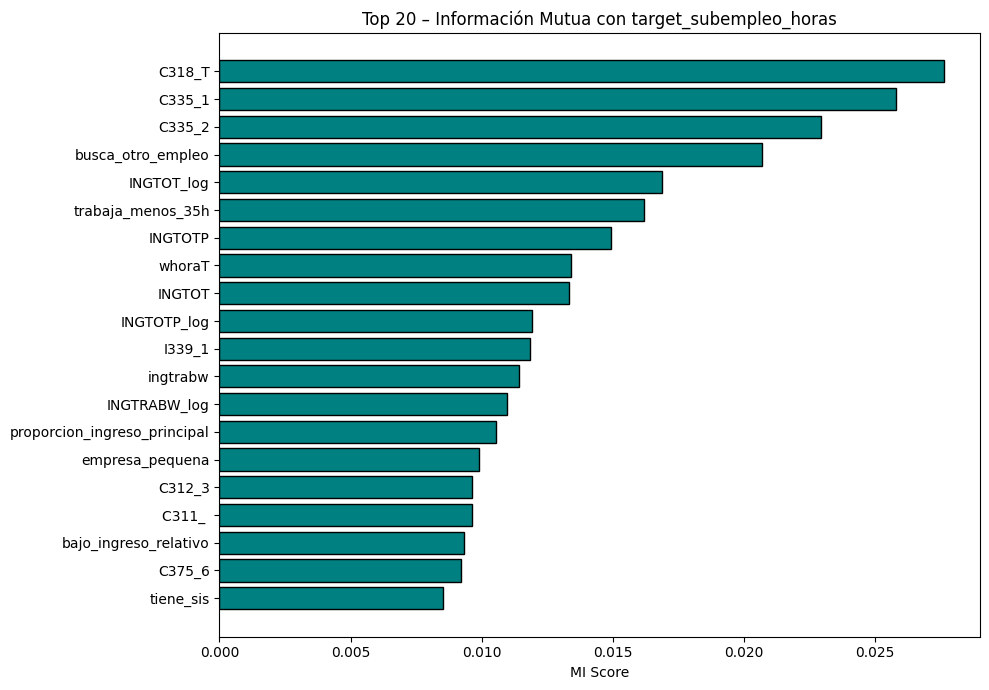

In [7]:
y_arr = y_train.values

mi_scores = mutual_info_classif(X_train_encoded, y_arr, random_state=42)
mi_df = (
    pd.DataFrame({"feature": X_train_encoded.columns, "mi_score": mi_scores})
    .sort_values("mi_score", ascending=False)
    .reset_index(drop=True)
)
mi_df["rank_mi"] = mi_df.index + 1

print("Top 30 – Información Mutua:")
print(mi_df.head(30).to_string(index=False))

top20_mi = mi_df.head(20).sort_values("mi_score")
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20_mi["feature"], top20_mi["mi_score"], color="teal", edgecolor="black")
ax.set_xlabel("MI Score")
ax.set_title("Top 20 – Información Mutua con target_subempleo_horas")
plt.tight_layout()
plt.show()

## 7. Método 2: Importancia por Random Forest

> Este RandomForest es **solo para estimar la importancia de las variables**, no es el modelo final.

Top 30 – Random Forest Importance:
                   feature  rf_importance  rank_rf
                    C318_T       0.050229        1
                      C208       0.048253        2
          ingreso_por_hora       0.045299        3
      ingreso_por_hora_log       0.045099        4
                    whoraT       0.040697        5
              INGTRABW_log       0.039418        6
                  ingtrabw       0.038107        7
               INGTOTP_log       0.035192        8
                   INGTOTP       0.034103        9
                INGTOT_log       0.033731       10
                    INGTOT       0.033225       11
                     C317A       0.030311       12
                    I339_1       0.021955       13
  ingreso_secundario_total       0.018067       14
                    C335_1       0.017230       15
         busca_otro_empleo       0.016689       16
                      C203       0.016297       17
                      C366       0.015880      

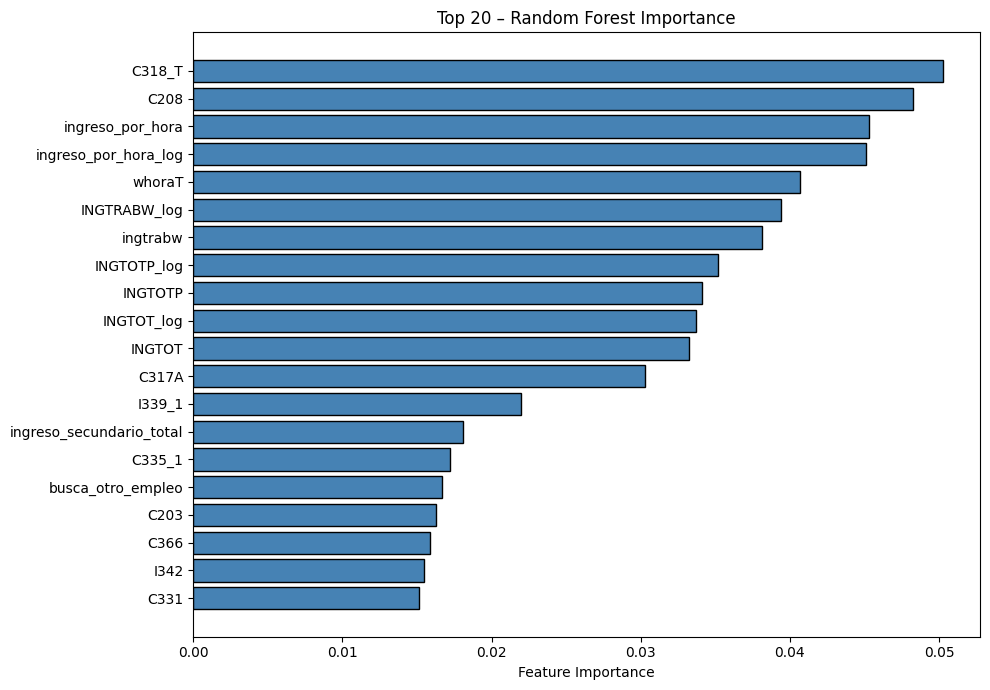

In [8]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
    max_depth=None,
)
rf.fit(X_train_encoded, y_arr)

rf_df = (
    pd.DataFrame({"feature": X_train_encoded.columns, "rf_importance": rf.feature_importances_})
    .sort_values("rf_importance", ascending=False)
    .reset_index(drop=True)
)
rf_df["rank_rf"] = rf_df.index + 1

print("Top 30 – Random Forest Importance:")
print(rf_df.head(30).to_string(index=False))

top20_rf = rf_df.head(20).sort_values("rf_importance")
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20_rf["feature"], top20_rf["rf_importance"], color="steelblue", edgecolor="black")
ax.set_xlabel("Feature Importance")
ax.set_title("Top 20 – Random Forest Importance")
plt.tight_layout()
plt.show()

## 8. Método 3: Coeficientes de Regresión Logística

> Este modelo es **solo para estimar la relevancia lineal de las variables**, no es el modelo final.

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)   # fit solo con train

logit = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="liblinear",
    random_state=42,
)
logit.fit(X_train_scaled, y_arr)

logit_df = (
    pd.DataFrame({
        "feature":        X_train_encoded.columns,
        "abs_logit_coef": np.abs(logit.coef_[0]),
    })
    .sort_values("abs_logit_coef", ascending=False)
    .reset_index(drop=True)
)
logit_df["rank_logit"] = logit_df.index + 1

print("Top 30 – Regresión Logística (|coeficiente|):")
print(logit_df.head(30).to_string(index=False))

Top 30 – Regresión Logística (|coeficiente|):
                          feature  abs_logit_coef  rank_logit
                     INGTRABW_log        0.612707           1
                       INGTOT_log        0.580197           2
                    tiene_pension        0.348079           3
                           C318_T        0.321180           4
         ingreso_secundario_total        0.298942           5
                           INGTOT        0.284112           6
trabajador_familiar_no_remunerado        0.252455           7
     universitaria_completa_o_mas        0.251099           8
                 trabajador_hogar        0.224623           9
                           C312_         0.207609          10
                   sector_publico        0.206291          11
                           C311_2        0.194370          12
                 horas_secundaria        0.190143          13
                             I342        0.185978          14
                        

## 9. Consolidación de Scores y Ranking Combinado

In [11]:
penalized_rank = n_features_encoded + 1

feature_selection_scores = (
    mi_df[["feature", "mi_score", "rank_mi"]]
    .merge(rf_df[["feature",    "rf_importance", "rank_rf"]],       on="feature", how="outer")
    .merge(logit_df[["feature", "abs_logit_coef", "rank_logit"]], on="feature", how="outer")
)

for rank_col in ["rank_mi", "rank_rf", "rank_logit"]:
    feature_selection_scores[rank_col] = feature_selection_scores[rank_col].fillna(penalized_rank)
for score_col in ["mi_score", "rf_importance", "abs_logit_coef"]:
    feature_selection_scores[score_col] = feature_selection_scores[score_col].fillna(0)

feature_selection_scores["combined_rank"] = (
    feature_selection_scores[["rank_mi", "rank_rf", "rank_logit"]].mean(axis=1)
)
feature_selection_scores = (
    feature_selection_scores
    .sort_values("combined_rank")
    .reset_index(drop=True)
)

print("Top 40 – Ranking Combinado:")
print(feature_selection_scores.head(40).to_string(index=False))

Top 40 – Ranking Combinado:
                 feature  mi_score  rank_mi  rf_importance  rank_rf  abs_logit_coef  rank_logit  combined_rank
                  C318_T  0.027623        1       0.050229        1        0.321180           4       2.000000
              INGTOT_log  0.016894        5       0.033731       10        0.580197           2       5.666667
            INGTRABW_log  0.010983       13       0.039418        6        0.612707           1       6.666667
                  INGTOT  0.013330        9       0.033225       11        0.284112           6       8.666667
                ingtrabw  0.011428       12       0.038107        7        0.148665          21      13.333333
                  C335_1  0.025788        2       0.017230       15        0.126953          25      14.000000
                  C335_2  0.022922        3       0.011409       22        0.162088          17      14.000000
       busca_otro_empleo  0.020702        4       0.016689       16        0.126953 

## 10. Selección Final de Variables

In [12]:
top_n = 30
selected_by_ranking = feature_selection_scores.head(top_n)["feature"].tolist()

# Variables conceptualmente importantes del dominio laboral/subempleo
conceptual_important = [
    "edad", "C208", "horas_totales", "whoraT",
    "ingreso_laboral_log", "INGTRABW_log",
    "ingreso_total_log",   "INGTOT_log",
    "nivel_educativo_ord", "C366",
    "posible_informalidad", "empresa_registrada_sunat",
    "tiene_seguro_salud",   "tiene_pension",
    "proteccion_social_completa",
]

available_cols = set(X_train_encoded.columns)
manual_features_added = [
    v for v in conceptual_important
    if v in available_cols and v not in selected_by_ranking
]

if manual_features_added:
    print(f"Variables agregadas manualmente (conceptual): {manual_features_added}")
else:
    print("Sin variables conceptuales adicionales (ya en ranking o no disponibles en X_train).")

records = (
    [{"selected_feature": f, "selection_source": "ranking"}           for f in selected_by_ranking] +
    [{"selected_feature": f, "selection_source": "manual_conceptual"} for f in manual_features_added]
)
selected_features_df = (
    pd.DataFrame(records)
    .drop_duplicates(subset="selected_feature")
    .reset_index(drop=True)
)

print(f"\nTotal variables seleccionadas: {len(selected_features_df)}")
print(selected_features_df.to_string(index=False))

Variables agregadas manualmente (conceptual): ['empresa_registrada_sunat', 'tiene_seguro_salud', 'proteccion_social_completa']

Total variables seleccionadas: 33
          selected_feature  selection_source
                    C318_T           ranking
                INGTOT_log           ranking
              INGTRABW_log           ranking
                    INGTOT           ranking
                  ingtrabw           ranking
                    C335_1           ranking
                    C335_2           ranking
         busca_otro_empleo           ranking
                      I342           ranking
         trabaja_menos_35h           ranking
                   INGTOTP           ranking
      ingreso_por_hora_log           ranking
  ingreso_secundario_total           ranking
          ingreso_por_hora           ranking
                      C377           ranking
                   SEGURO1           ranking
               INGTOTP_log           ranking
                      C208  

## 11. Agrupación Conceptual de Variables Seleccionadas

In [13]:
def assign_group(f: str) -> str:
    fl = f.lower()
    if any(k in fl for k in ["edad", "sexo", "c208", "area", "urbano", "rural", "region", "dominio", "genero"]):
        return "Demográficas"
    if any(k in fl for k in ["educ", "nivel_educ", "c360", "c361", "c362", "c363", "c364", "c365", "c366",
                              "estudio", "escolar", "universitario"]):
        return "Educación"
    if any(k in fl for k in ["hora", "whorat", "c350", "c351", "c352", "c353", "horas_total"]):
        return "Horas"
    if any(k in fl for k in ["ingreso", "ingtrab", "ingtot", "remuner", "salario", "_log", "c400", "c401"]):
        return "Ingresos"
    if any(k in fl for k in ["formal", "informal", "sunat", "registro", "empresa", "c330", "c331", "c332",
                              "informalidad"]):
        return "Empleo/Formalidad"
    if any(k in fl for k in ["pension", "seguro", "salud", "proteccion", "social", "essalud", "afp", "sis",
                              "afiliado"]):
        return "Protección social"
    if any(k in fl for k in ["discapac", "c210", "c211", "c212"]):
        return "Discapacidad"
    if any(k in fl for k in ["etnia", "indigena", "quechua", "aymara", "amazonia", "mestizo", "c215", "pueblo"]):
        return "Etnicidad"
    if any(k in fl for k in ["flag_", "tiene_", "es_", "posible_", "ha_"]):
        return "Flags"
    return "Otros"


selected_features_df = selected_features_df.copy()
selected_features_df["feature_group"] = selected_features_df["selected_feature"].apply(assign_group)

print("Distribución por grupo conceptual:")
group_tbl = (
    selected_features_df.groupby("feature_group")
    .agg(cantidad_variables=("selected_feature", "count"))
    .sort_values("cantidad_variables", ascending=False)
)
print(group_tbl.to_string())

print("\nDetalle:")
print(
    selected_features_df[["selected_feature", "feature_group", "selection_source"]]
    .to_string(index=False)
)

Distribución por grupo conceptual:
                   cantidad_variables
feature_group                        
Otros                              12
Ingresos                            7
Protección social                   5
Horas                               4
Demográficas                        2
Educación                           2
Empleo/Formalidad                   1

Detalle:
          selected_feature     feature_group  selection_source
                    C318_T             Otros           ranking
                INGTOT_log          Ingresos           ranking
              INGTRABW_log          Ingresos           ranking
                    INGTOT          Ingresos           ranking
                  ingtrabw          Ingresos           ranking
                    C335_1             Otros           ranking
                    C335_2             Otros           ranking
         busca_otro_empleo             Otros           ranking
                      I342             Otros  

## 12. Creación de Datasets con Variables Seleccionadas

In [14]:
valid_selected = [
    f for f in selected_features_df["selected_feature"].tolist()
    if f in X_train_encoded.columns
]
missing_feats = [
    f for f in selected_features_df["selected_feature"].tolist()
    if f not in X_train_encoded.columns
]
if missing_feats:
    print(f"ADVERTENCIA – Features no disponibles en X_train_encoded: {missing_feats}")

X_train_selected = X_train_encoded[valid_selected].copy()
X_test_selected  = X_test_encoded[valid_selected].copy()
y_train_selected = y_train.reset_index(drop=True)
y_test_selected  = y_test.reset_index(drop=True)

# Validaciones
assert list(X_train_selected.columns) == list(X_test_selected.columns), \
    "X_train_selected y X_test_selected no coinciden en columnas."
assert TARGET_COL not in X_train_selected.columns, \
    f"'{TARGET_COL}' presente en X_train_selected."
for lv in ["P209H", "C333", "C334"]:
    assert lv not in X_train_selected.columns, \
        f"Variable de leakage '{lv}' presente en X_train_selected."
assert X_train_selected.isnull().sum().sum() == 0, "X_train_selected tiene nulos."
assert X_test_selected.isnull().sum().sum() == 0,  "X_test_selected tiene nulos."
assert all(X_train_selected.dtypes != "object"), \
    "X_train_selected tiene columnas no numéricas."

print("Validaciones OK.")
print(f"\nX_train_selected : {X_train_selected.shape}")
print(f"X_test_selected  : {X_test_selected.shape}")
print(f"y_train_selected : {y_train_selected.shape}")
print(f"y_test_selected  : {y_test_selected.shape}")
print(f"\nVariables finales ({len(valid_selected)}):")
print(valid_selected)

Validaciones OK.

X_train_selected : (19243, 33)
X_test_selected  : (4811, 33)
y_train_selected : (19243,)
y_test_selected  : (4811,)

Variables finales (33):
['C318_T', 'INGTOT_log', 'INGTRABW_log', 'INGTOT', 'ingtrabw', 'C335_1', 'C335_2', 'busca_otro_empleo', 'I342', 'trabaja_menos_35h', 'INGTOTP', 'ingreso_por_hora_log', 'ingreso_secundario_total', 'ingreso_por_hora', 'C377', 'SEGURO1', 'INGTOTP_log', 'C208', 'horas_secundaria', 'I339_1', 'tiene_pension', 'C207', 'whoraT', 'tiene_sis', 'C361_5', 'C328_T', 'C366', 'grupo_edad_35_44', 'jefe_hogar', 'C311_ ', 'empresa_registrada_sunat', 'tiene_seguro_salud', 'proteccion_social_completa']


## 13. Guardar Archivos de Salida

In [15]:
# selected_features_df filtrado a lo que efectivamente está disponible
selected_features_final = selected_features_df[
    selected_features_df["selected_feature"].isin(valid_selected)
].copy()

# Resumen de feature selection
feature_selection_summary = pd.DataFrame([{
    "n_features_original":       X_train.shape[1],
    "n_features_after_cleaning": X_train_fs.shape[1],
    "n_features_encoded":        n_features_encoded,
    "n_features_selected":       len(valid_selected),
    "n_manual_features_added":   len(manual_features_added),
    "train_rows":                X_train_selected.shape[0],
    "test_rows":                 X_test_selected.shape[0],
}])

# ── Guardar ───────────────────────────────────────────────────────────────
X_train_selected.to_csv(SELECTED_DIR / "X_train_selected.csv", index=False)
X_test_selected.to_csv(SELECTED_DIR  / "X_test_selected.csv",  index=False)
y_train_selected.to_frame(name=TARGET_COL).to_csv(
    SELECTED_DIR / "y_train_selected.csv", index=False
)
y_test_selected.to_frame(name=TARGET_COL).to_csv(
    SELECTED_DIR / "y_test_selected.csv", index=False
)
selected_features_final.to_csv(
    SELECTED_DIR / "selected_features.csv", index=False
)
feature_selection_scores.to_csv(
    SELECTED_DIR / "feature_selection_scores.csv", index=False
)
feature_selection_summary.to_csv(
    SELECTED_DIR / "feature_selection_summary.csv", index=False
)

# ── Verificar ─────────────────────────────────────────────────────────────
print(f"Archivos guardados en: {SELECTED_DIR.resolve()}\n")
expected_files = [
    "X_train_selected.csv",
    "X_test_selected.csv",
    "y_train_selected.csv",
    "y_test_selected.csv",
    "selected_features.csv",
    "feature_selection_scores.csv",
    "feature_selection_summary.csv",
    "constant_features.csv",
    "quasi_constant_features.csv",
    "duplicate_features.csv",
]
for fname in expected_files:
    status = "OK" if (SELECTED_DIR / fname).exists() else "NO ENCONTRADO"
    print(f"  [{status}] {fname}")

print("\nResumen de selección:")
print(feature_selection_summary.T.to_string(header=False))

Archivos guardados en: C:\Users\ADMIN\Desktop\ML_PROYECTO_26_1\ml_project\data\selected

  [OK] X_train_selected.csv
  [OK] X_test_selected.csv
  [OK] y_train_selected.csv
  [OK] y_test_selected.csv
  [OK] selected_features.csv
  [OK] feature_selection_scores.csv
  [OK] feature_selection_summary.csv
  [OK] constant_features.csv
  [OK] quasi_constant_features.csv
  [OK] duplicate_features.csv

Resumen de selección:
n_features_original          113
n_features_after_cleaning    101
n_features_encoded           138
n_features_selected           33
n_manual_features_added        3
train_rows                 19243
test_rows                   4811


## 14. Conclusiones

- La selección de variables se realizó usando **únicamente el conjunto de entrenamiento** (`X_train`), evitando data leakage.
- Antes de los métodos de selección se eliminaron variables **constantes** y **duplicadas exactas**, y se documentaron las **casi constantes**.
- Se aplicaron tres criterios independientes de selección:
  - **Información Mutua**: captura dependencias no lineales entre cada predictor y el target.
  - **Random Forest Importance**: refleja la relevancia en un modelo de ensamblado.
  - **Regresión Logística** (coeficientes absolutos): refleja la importancia lineal tras estandarización.
- Los tres rankings se consolidaron en un **ranking combinado** (promedio de rangos).
- Se verificó la presencia de variables conceptualmente clave del dominio laboral; las ausentes del ranking automático se incorporaron manualmente si estaban disponibles.
- El conjunto de prueba (`X_test`) fue **únicamente filtrado** al final usando la lista de variables seleccionadas desde `X_train`; no participó en ningún criterio de selección.
- Los archivos generados en `../data/selected/` quedan listos para la etapa de modelamiento (`07_modelling/`).